## Notebook to train random forrest model


### Importing libraries and creates constants

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

from imblearn.under_sampling import RandomUnderSampler
from image_processing import read_img,show_img
from ml_utilitis import extract_features,extract_label,save_model,predict_full_image,remove_small_components
from sklearn.metrics import root_mean_squared_error 
from simple_statistics import create_confusions_matrix
from image_processing import preproces_pipeline,postproces_pipeline
import os

import numpy as np

INPUT_DIR:str="./images"
MANUAL_DIR:str="./manual1"
MASK_DIR:str="./mask"
SAVED_MODELS:str="./saved_models"

KERNEL_SIZE:int=5


### Loading data

In [2]:
input_images=[INPUT_DIR+"/"+file.name for file in os.scandir(INPUT_DIR) if file.is_file()]
manual_images=[MANUAL_DIR+"/"+file.name for file in os.scandir(MANUAL_DIR) if file.is_file()]
mask_images=[MASK_DIR+"/"+file.name for file in os.scandir("./mask") if file.is_file()]

data=list(zip(input_images,manual_images,mask_images))

print(f"Total number of images: {len(data)}")
max_test_id=int(len(data)*0.80)
print(f"Number of images used to train the model: {max_test_id}")

Total number of images: 45
Number of images used to train the model: 36


### Colecting feauters and labels to training

In [3]:
all_features=[]
all_lebels=[]
for idx,element in enumerate(data):
    img=read_img(element[0])
    img=preproces_pipeline(img,11)

    manual_=read_img(element[1])
    manual_=manual_[:,:,1]
    manual_=np.where(manual_>0,1,0)

    mask_=read_img(element[2])

    max_x,max_y=img.shape
    center_x,center_y=max_x//2,max_y//2

    half = KERNEL_SIZE // 2

    for x in range(half,max_x-half):

        for y in range(half,max_y-half):
            #Only point in the FOV are important
            if mask_[x,y,1]==0:
                continue
            patch = img[x-half:x+half+1,y-half:y+half+1]

            label_patch = manual_[x-half:x+half+1,y-half:y+half+1]

            features_sample = extract_features(patch)

            all_features.append(features_sample)

            all_lebels.append(
                extract_label(label_patch, KERNEL_SIZE)
            )
            #Max number of samples from a single image is equal to 25 000 points
            if len(all_features)>(idx+1)*25_000:
                break
        if idx>=max_test_id:
            break




### Balancing data set and spliting it for the train data set and the test data set

In [4]:
X_train, X_test, y_train, y_test = train_test_split(all_features, all_lebels, test_size=0.25, random_state=42)
#Test data sed is used only once, later whole images are used 

random_under_sampler=RandomUnderSampler(sampling_strategy=1.0,random_state=42)
X_train,y_train=random_under_sampler.fit_resample(X_train,y_train)
print(f"Number of positive values in the training data set: {y_train.count(1)}")
print(f"Number of negative values in the training data set: {y_train.count(0)}")



Number of positive values in the training data set: 46598
Number of negative values in the training data set: 46598


### Creating and training the model

In [5]:
clasifier=RandomForestClassifier(random_state=42, n_jobs=-1)
parameters={'n_estimators':[100,150],
           'max_depth':[20,30],
           'min_samples_split':[2,5],
}

grid_search=GridSearchCV(clasifier,parameters,n_jobs=-1,scoring="f1",cv=5)
grid_search.fit(X_train,y_train)



,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [20, 30], 'min_samples_split': [2, 5], 'n_estimators': [100, 150]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,150


### Saving the model in ```saved_models``` directory

In [6]:
save_model(grid_search,SAVED_MODELS+"/"+"random_forrest")

### Making prediction for the test data set and displaying confussions matrix

0.42936956089390516


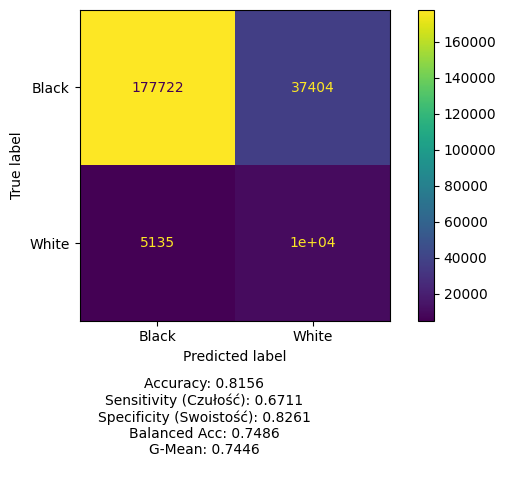

4709

In [7]:
predictions=grid_search.predict(X_test)
print(root_mean_squared_error(y_test,predictions))
create_confusions_matrix(np.array(y_test),np.array(predictions))

#Deleting and cleaning redundat data
del X_train
del y_train
del X_test
del y_test

import gc
gc.collect()

### Testing on unknown images with postprocessing, cleaning and pipeline


In [ ]:
for idx,element in enumerate (list(data)[-2::]):
    img=read_img(element[0])
    manual=read_img(element[1])
    mask=read_img(element[2])

    returned_img=predict_full_image(img,mask,grid_search,preproces_pipeline)
    show_img(returned_img,f"Image: {element[0]} after prediction")

    manual=manual[:,:,1]
    manual=np.where(manual>0,1,0)
    
    create_confusions_matrix(manual,returned_img)
    
    cleaned=remove_small_components(returned_img,100)
    show_img(cleaned,f"Image: {element[0]} after prediction and cleaning")
    cleaned=postproces_pipeline(cleaned,13)
    
    show_img(cleaned,f"Image: {element[0]} after prediction, cleaning and postprocessing")
    create_confusions_matrix(manual,cleaned)

    if idx>2:
        break